# Module 2i — Incremental Ingestion

- **Chapter 2, Module I of 14** — [chapter index](../README.md)
- **Prerequisites:** [2h — Deduplication & Versioning](../2h.%20Deduplication%20and%20versioning/)
- **Next:** [2j — Tables, Images & Special Formats](../2j.%20Tables%20images%20and%20special%20formats/)

## The one idea

The first ingestion run is easy: process everything. Every run after that faces a different
problem — **most of the corpus has not changed**, and reprocessing it wastes money, time, and
embedding API quota, while leaving the index unavailable or inconsistent in the meantime.

Incremental ingestion means doing the minimum work: detect what actually changed, re-process
only that, and swap it into the index without ever leaving the index in a broken state. The
hard parts are not the happy path — they are **deletions**, **stable IDs**, and **idempotency**.

**By the end you will be able to:**

1. Detect changed, added and deleted documents by comparing manifests
2. Explain why deletion is the case naive pipelines always get wrong
3. Design chunk IDs that stay stable when a document is edited
4. Make an ingestion run idempotent, so re-running it changes nothing
5. Replace an index atomically, so readers never see a half-updated state

## Module roadmap

```mermaid
flowchart LR
    A["Previous manifest"] --> C["Diff"]
    B["Current source scan"] --> C
    C --> D["ADDED - process"]
    C --> E["MODIFIED - reprocess"]
    C --> F["DELETED - remove from index"]
    C --> G["UNCHANGED - skip entirely"]
    D --> H["Atomic index swap"]
    E --> H
    F --> H
```

![Diagram](diagrams/cell00-90f1d21abf.svg)


## Setup

In [1]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch, CORPUS


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<16} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<16} available")
    return module


print("Libraries:")

# PyMuPDF parses the real PDFs we will chunk and re-chunk.
pymupdf = (try_import("pymupdf", "PyMuPDF", "pip install pymupdf")
           or try_import("fitz", "PyMuPDF (legacy)", "pip install pymupdf"))

# Standard library modules used throughout.
import hashlib
import json
import shutil
from datetime import datetime, timezone
from pathlib import Path

print("  [x] hashlib, json, shutil, datetime, pathlib  (standard library)")

Libraries:
  [x] PyMuPDF          available
  [x] hashlib, json, shutil, datetime, pathlib  (standard library)


# 1. The manifest: a record of what you last ingested

**The intuition before the code.** You cannot detect change without remembering the previous
state. A **manifest** is that memory: one entry per source document, recording its identity
and a fingerprint of its content at the time you last processed it.

Crucially, the fingerprint must be **content-based** (a hash), not metadata-based. File
modification timestamps lie constantly: a file copied between machines gets a new mtime with
identical content, and some sync tools preserve mtime while changing content.

```mermaid
flowchart LR
    A["Source documents"] --> B["Hash each one"]
    B --> C["Manifest:\ndoc_id to content hash"]
    C --> D["Saved to disk"]
    D --> E["Next run compares\nagainst this"]
```

![Diagram](diagrams/cell03-f40df18f2e.svg)


In [2]:
# Define a function that fingerprints a real file by its content, not its metadata.
def file_fingerprint(path):

    # Read the real bytes and hash them - the only reliable change signal.
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


# Define a function that builds a manifest over a set of real corpus documents.
def build_manifest(corpus_keys):

    manifest = {}

    for key in corpus_keys:

        # Fetch the real document (cached after the first run).
        path = fetch(key, quiet=True)

        # Record identity, fingerprint, and the facts needed to detect change.
        manifest[key] = {
            "path": str(path),
            "content_sha256": file_fingerprint(path),
            "size_bytes": Path(path).stat().st_size,
            "scanned_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        }

    return manifest


# Build a real manifest over three real corpus documents.
CORPUS_KEYS = ["gdpr_pdf", "rag_paper", "titanic_csv"]
manifest_v1 = build_manifest(CORPUS_KEYS)

print("Real manifest, one entry per real source document:\n")
for key, entry in manifest_v1.items():
    print(f"  {key:14s} {entry['size_bytes']:>9,} bytes  "
          f"sha256={entry['content_sha256'][:16]}...")

Real manifest, one entry per real source document:

  gdpr_pdf         982,296 bytes  sha256=bd84e63f5b622b73...
  rag_paper        885,323 bytes  sha256=23e3249e9a1e7541...
  titanic_csv       60,302 bytes  sha256=4a437fde05fe5264...


## 1.1 Why mtime is not good enough

**The intuition before the code.** This is worth proving rather than asserting, because
"just check the modification time" is the first thing everyone reaches for — it is far cheaper
than hashing. It is also wrong in both directions.

In [3]:
# Demonstrate both failure modes on real files in a scratch directory.
scratch = Path("_incremental_demo")
scratch.mkdir(exist_ok=True)

# Write a real file, record its real mtime and hash.
original_file = scratch / "policy.txt"
original_file.write_text("The controller shall implement appropriate measures.")

mtime_before = original_file.stat().st_mtime
hash_before = file_fingerprint(original_file)

# FAILURE MODE 1 - content unchanged, but mtime updated (a copy, or a no-op rewrite).
import os, time
time.sleep(0.01)
os.utime(original_file, None)   # touch it, exactly as a sync tool might

mtime_after_touch = original_file.stat().st_mtime
hash_after_touch = file_fingerprint(original_file)

print("FAILURE MODE 1 - touched file, identical content:\n")
print(f"  mtime changed   : {mtime_before != mtime_after_touch}   <- mtime says REPROCESS")
print(f"  content changed : {hash_before != hash_after_touch}  <- hash correctly says SKIP")

# FAILURE MODE 2 - content changed, but mtime forced back to the old value.
original_file.write_text("The controller shall implement APPROPRIATE measures.")
os.utime(original_file, (mtime_before, mtime_before))   # restore the old mtime

mtime_after_edit = original_file.stat().st_mtime
hash_after_edit = file_fingerprint(original_file)

print("\nFAILURE MODE 2 - edited file, mtime restored to its old value:\n")
print(f"  mtime changed   : {mtime_before != mtime_after_edit}  <- mtime says SKIP (WRONG)")
print(f"  content changed : {hash_before != hash_after_edit}   <- hash correctly says REPROCESS")

print("\nMode 2 is the dangerous one: a real edit silently never reaches the index.")

FAILURE MODE 1 - touched file, identical content:

  mtime changed   : True   <- mtime says REPROCESS
  content changed : False  <- hash correctly says SKIP

FAILURE MODE 2 - edited file, mtime restored to its old value:

  mtime changed   : False  <- mtime says SKIP (WRONG)
  content changed : True   <- hash correctly says REPROCESS

Mode 2 is the dangerous one: a real edit silently never reaches the index.


**Failure mode 2 is why content hashing is not optional.** An mtime-based pipeline fails
*silently* and *permanently* — the document is never reprocessed, and nothing reports an error.

# 2. Diffing two manifests

**The intuition before the code.** With a previous manifest and a current scan, change
detection becomes simple set arithmetic. Four outcomes, and the fourth is the one that matters
most for cost:

| Outcome | Condition | Action |
|---|---|---|
| **ADDED** | in current, not in previous | process and index |
| **MODIFIED** | in both, hash differs | reprocess, replace existing chunks |
| **DELETED** | in previous, not in current | remove existing chunks from the index |
| **UNCHANGED** | in both, hash identical | do nothing at all |

```mermaid
flowchart LR
    A["Previous manifest keys"] --> C{"Set comparison"}
    B["Current manifest keys"] --> C
    C -->|"current - previous"| D["ADDED"]
    C -->|"previous - current"| E["DELETED"]
    C -->|"in both, hash differs"| F["MODIFIED"]
    C -->|"in both, hash same"| G["UNCHANGED"]
```

![Diagram](diagrams/cell07-968f455c3d.svg)


In [4]:
# Define a function that diffs two manifests into the four outcomes.
def diff_manifests(previous, current):

    previous_keys = set(previous)
    current_keys = set(current)

    # Simple set arithmetic gives added and deleted directly.
    added = sorted(current_keys - previous_keys)
    deleted = sorted(previous_keys - current_keys)

    # For keys present in both, the content hash decides modified vs unchanged.
    modified = sorted(
        key for key in previous_keys & current_keys
        if previous[key]["content_sha256"] != current[key]["content_sha256"]
    )
    unchanged = sorted(
        key for key in previous_keys & current_keys
        if previous[key]["content_sha256"] == current[key]["content_sha256"]
    )

    return {"added": added, "modified": modified,
            "deleted": deleted, "unchanged": unchanged}


# Simulate a realistic second run: one document added, one removed, one edited.
manifest_v2 = dict(manifest_v1)

# ADDED - a new real document appears in the corpus.
manifest_v2["gdpr_html"] = build_manifest(["gdpr_html"])["gdpr_html"]

# DELETED - a document is removed from the source.
del manifest_v2["titanic_csv"]

# MODIFIED - a real document's content changed upstream (simulated by a new hash).
manifest_v2["rag_paper"] = dict(manifest_v2["rag_paper"])
manifest_v2["rag_paper"]["content_sha256"] = hashlib.sha256(b"edited upstream").hexdigest()

# Diff the two real manifests.
changes = diff_manifests(manifest_v1, manifest_v2)

print("Change detection between run 1 and run 2:\n")
for outcome in ["added", "modified", "deleted", "unchanged"]:
    print(f"  {outcome.upper():10s} {changes[outcome]}")

total = sum(len(v) for v in changes.values())
work = len(changes["added"]) + len(changes["modified"]) + len(changes["deleted"])
print(f"\n  Documents examined : {total}")
print(f"  Requiring work     : {work}")
print(f"  Skipped entirely   : {len(changes['unchanged'])} "
      f"({len(changes['unchanged'])/total:.0%} of the corpus)")

Change detection between run 1 and run 2:

  ADDED      ['gdpr_html']
  MODIFIED   ['rag_paper']
  DELETED    ['titanic_csv']
  UNCHANGED  ['gdpr_pdf']

  Documents examined : 4
  Requiring work     : 3
  Skipped entirely   : 1 (25% of the corpus)


# 3. Deletion: the case everyone gets wrong

**The intuition before the code.** Adding and updating are visible — someone notices when a new
document is missing from search results. Deletion fails **invisibly in the opposite direction**:
the document is gone from the source, but its chunks remain in the index forever, and retrieval
keeps confidently citing a document that no longer exists.

This is worse than it sounds in a regulated setting. A policy that was *withdrawn* is still
being quoted as current, with a citation that looks completely legitimate.

The reason it gets missed: a pipeline that iterates over *current source documents* structurally
cannot see a deletion. Nothing in that loop ever visits the missing document. You can only find
deletions by comparing against the **previous** state.

```mermaid
flowchart LR
    A["for doc in current_sources"] --> B["Sees ADDED"]
    A --> C["Sees MODIFIED"]
    A --> D["Never sees DELETED\n- the loop never visits it"]
    E["Diff against previous manifest"] --> F["Deletions become visible"]
```

![Diagram](diagrams/cell09-0ec8e1577a.svg)


In [5]:
# Demonstrate the bug concretely with a naive pipeline versus a diff-based one.

# A simulated index: chunk records keyed by the document they came from.
simulated_index = {
    "gdpr_pdf": ["chunk_1", "chunk_2", "chunk_3"],
    "rag_paper": ["chunk_4", "chunk_5"],
    "titanic_csv": ["chunk_6"],
}

print(f"Index before run 2: {sum(len(v) for v in simulated_index.values())} chunks "
      f"across {len(simulated_index)} documents")
print(f"  {dict((k, len(v)) for k, v in simulated_index.items())}\n")


# THE NAIVE PIPELINE - iterate over current sources only.
naive_index = dict((k, list(v)) for k, v in simulated_index.items())
for key in manifest_v2:                      # only CURRENT documents
    if key in changes["added"] or key in changes["modified"]:
        naive_index[key] = [f"new_chunk_{key}"]

print("NAIVE pipeline (iterates current sources only):")
print(f"  {dict((k, len(v)) for k, v in naive_index.items())}")
print(f"  titanic_csv still indexed : {'titanic_csv' in naive_index}  <- BUG")
print(f"  It was deleted from the source, but its chunks remain retrievable.\n")


# THE DIFF-BASED PIPELINE - handles all four outcomes.
correct_index = dict((k, list(v)) for k, v in simulated_index.items())
for key in changes["added"] + changes["modified"]:
    correct_index[key] = [f"new_chunk_{key}"]
for key in changes["deleted"]:
    del correct_index[key]                   # the step the naive version cannot reach

print("DIFF-BASED pipeline (handles deletions):")
print(f"  {dict((k, len(v)) for k, v in correct_index.items())}")
print(f"  titanic_csv still indexed : {'titanic_csv' in correct_index}  <- correct")

Index before run 2: 6 chunks across 3 documents
  {'gdpr_pdf': 3, 'rag_paper': 2, 'titanic_csv': 1}

NAIVE pipeline (iterates current sources only):
  {'gdpr_pdf': 3, 'rag_paper': 1, 'titanic_csv': 1, 'gdpr_html': 1}
  titanic_csv still indexed : True  <- BUG
  It was deleted from the source, but its chunks remain retrievable.

DIFF-BASED pipeline (handles deletions):
  {'gdpr_pdf': 3, 'rag_paper': 1, 'gdpr_html': 1}
  titanic_csv still indexed : False  <- correct


# 4. Stable chunk IDs

**The intuition before the code.** When a document changes, you must replace its chunks. That
requires being able to *find* the old chunks — which requires IDs that are predictable rather
than random.

A naive `uuid4()` per chunk makes this impossible: after reprocessing you have no way to match
new chunks to old ones, so you must delete everything for that document and re-insert.

The better approach is a **deterministic ID derived from stable inputs**. The subtlety is
choosing those inputs carefully:

| ID scheme | Behaviour on edit | Behaviour on insert |
|---|---|---|
| `uuid4()` | new ID every run — cannot match old to new at all | same |
| `doc_id + chunk_index` | **ID unchanged even though the text changed** | positions shift |
| `doc_id + hash(chunk_text)` | edited chunk gets a new ID, which is correct | untouched chunks keep their IDs |

Read the middle row carefully, because it is the trap. A position-based ID looks appealingly
cheap — an edit produces *zero* new IDs, so nothing needs re-embedding. That is not a saving,
it is a **silent correctness failure**: the ID is reused while the text underneath it changed,
so unless the write path happens to overwrite by ID, the index keeps serving the old text
forever with no error.

We are about to measure exactly that on the real GDPR document, and the number will look like
the position scheme "winning" until you ask what it actually means.

```mermaid
flowchart LR
    A["Paragraph text is edited"] --> B{"ID scheme?"}
    B -->|"doc + index"| C["Same ID, new text.\nChange is INVISIBLE\nto the index."]
    B -->|"doc + content hash"| D["New ID.\nChange is detected\nand re-embedded."]
```

![Diagram](diagrams/cell11-f68bf58818.svg)


In [6]:
# Define the two competing ID schemes so we can measure the difference.
def chunk_id_by_index(doc_id, chunk_index, chunk_text):

    # Position-based: stable only if nothing is ever inserted or removed.
    return f"{doc_id}:idx:{chunk_index}"


def chunk_id_by_content(doc_id, chunk_index, chunk_text):

    # Content-based: the ID follows the text, not its position.
    digest = hashlib.sha256(chunk_text.encode("utf-8")).hexdigest()[:16]
    return f"{doc_id}:sha:{digest}"


# A realistic document, as a list of paragraphs.
paragraphs_v1 = [
    "Article 1. Subject-matter and objectives.",
    "This Regulation lays down rules relating to the protection of natural persons.",
    "This Regulation protects fundamental rights and freedoms of natural persons.",
    "The free movement of personal data within the Union shall be neither restricted nor prohibited.",
]

# Version 2: ONE new paragraph inserted near the top. Everything else is untouched.
paragraphs_v2 = [
    "Article 1. Subject-matter and objectives.",
    "AMENDED: This Regulation lays down rules relating to the protection of natural persons.",
    "This Regulation lays down rules relating to the protection of natural persons.",
    "This Regulation protects fundamental rights and freedoms of natural persons.",
    "The free movement of personal data within the Union shall be neither restricted nor prohibited.",
]

# Build an index under each scheme from v1, then apply v2 and see what the index HOLDS.
for scheme_name, id_function in [("BY INDEX", chunk_id_by_index),
                                  ("BY CONTENT HASH", chunk_id_by_content)]:

    # Index version 1: id -> the text stored under it.
    index_v1 = {id_function("gdpr", i, t): t for i, t in enumerate(paragraphs_v1)}

    # Now version 2 arrives. Which IDs are genuinely new?
    ids_v2 = {id_function("gdpr", i, t) for i, t in enumerate(paragraphs_v2)}
    new_ids = ids_v2 - set(index_v1)

    # THE REAL QUESTION: if we only re-embed the NEW ids, does the index end up
    # holding the correct v2 text, or does it keep stale v1 text under a reused id?
    stale = 0
    for position, text in enumerate(paragraphs_v2):
        cid = id_function("gdpr", position, text)
        if cid in index_v1 and index_v1[cid] != text:
            stale = stale + 1

    print(f"{scheme_name}:")
    print(f"  IDs needing re-embedding : {len(new_ids)} of {len(ids_v2)}")
    print(f"  Chunks left holding STALE text : {stale}")
    print()

BY INDEX:
  IDs needing re-embedding : 1 of 5
  Chunks left holding STALE text : 3

BY CONTENT HASH:
  IDs needing re-embedding : 1 of 5
  Chunks left holding STALE text : 0



**Look at the stale count, not the re-embedding count.** The position scheme reports fewer
chunks to re-embed — and leaves chunks holding text that no longer matches the source. The
content scheme re-embeds more, and leaves nothing stale. Cheaper is not the same as correct.

## 4.1 Measuring it on the real GDPR document

Let's scale this up to a real document, measuring both the cost and the staleness.

In [7]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Chunk the real GDPR PDF into real paragraphs.
    gdpr_path = fetch("gdpr_pdf", quiet=True)
    document = pymupdf.open(gdpr_path)
    gdpr_full_text = "\n".join(
        document.load_page(i).get_text("text") for i in range(len(document))
    )
    document.close()

    # Split into real paragraphs, dropping empties.
    real_paragraphs = [p.strip() for p in gdpr_full_text.split("\n\n") if p.strip()]

    print(f"  Real paragraphs in the GDPR PDF : {len(real_paragraphs):,}\n")

    # Simulate a realistic upstream edit: change ONE paragraph in the middle.
    edit_position = len(real_paragraphs) // 2
    edited_paragraphs = list(real_paragraphs)
    edited_paragraphs[edit_position] = "AMENDED: " + edited_paragraphs[edit_position]

    # Define a function measuring BOTH the cost and the correctness of a scheme.
    def measure_scheme(original, changed, id_function):

        # The index as built from the ORIGINAL text.
        index = {id_function("gdpr", i, t): t for i, t in enumerate(original)}

        # IDs that are genuinely new, so a pipeline would re-embed them.
        new_ids = {id_function("gdpr", i, t) for i, t in enumerate(changed)} - set(index)

        # Chunks whose ID was reused while the text underneath changed - stale entries
        # a pipeline keying on ID would never notice.
        stale = sum(
            1 for position, text in enumerate(changed)
            if (cid := id_function("gdpr", position, text)) in index and index[cid] != text
        )

        return len(new_ids), stale


    # Report the real numbers for a pure EDIT.
    print("  After EDITING one paragraph in the middle:\n")
    print(f"  {'scheme':<18} {'re-embed':>10} {'STALE':>8}")
    for scheme_name, id_function in [("by index", chunk_id_by_index),
                                      ("by content hash", chunk_id_by_content)]:
        rework, stale = measure_scheme(real_paragraphs, edited_paragraphs, id_function)
        print(f"  {scheme_name:<18} {rework:>10,} {stale:>8,}")

    print("\n  The index scheme re-embeds NOTHING - and leaves a chunk holding text")
    print("  that no longer exists in the source. That is the silent-staleness bug.")

    # Now simulate an INSERTION, which is worse still for position-based IDs.
    inserted_paragraphs = (real_paragraphs[:edit_position]
                            + ["NEW: an inserted recital."]
                            + real_paragraphs[edit_position:])

    print("\n  After INSERTING one paragraph in the middle:\n")
    print(f"  {'scheme':<18} {'re-embed':>10} {'STALE':>8}")
    for scheme_name, id_function in [("by index", chunk_id_by_index),
                                      ("by content hash", chunk_id_by_content)]:
        rework, stale = measure_scheme(real_paragraphs, inserted_paragraphs, id_function)
        print(f"  {scheme_name:<18} {rework:>10,} {stale:>8,}")

    print("\n  Every paragraph after the insertion point shifted by one position, so")
    print("  under the index scheme each one now holds its NEIGHBOUR'S text.")

  Real paragraphs in the GDPR PDF : 88

  After EDITING one paragraph in the middle:

  scheme               re-embed    STALE
  by index                    0        1
  by content hash             1        0

  The index scheme re-embeds NOTHING - and leaves a chunk holding text
  that no longer exists in the source. That is the silent-staleness bug.

  After INSERTING one paragraph in the middle:

  scheme               re-embed    STALE
  by index                    1       44
  by content hash             1        0

  Every paragraph after the insertion point shifted by one position, so
  under the index scheme each one now holds its NEIGHBOUR'S text.


## 4.2 Seeing cost against correctness

The two numbers pull in opposite directions, so plot them together. A scheme that re-embeds
less while leaving stale chunks behind is not cheaper — it is broken.

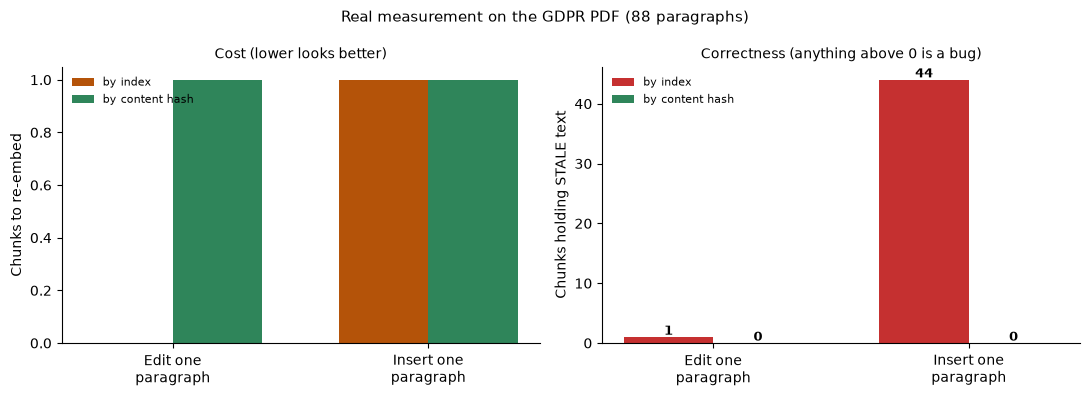

In [8]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    import matplotlib.pyplot as plt
    import numpy as np

    # Collect the real measurements for both scenarios and both schemes.
    scenarios = [
        ("Edit one\nparagraph", real_paragraphs, edited_paragraphs),
        ("Insert one\nparagraph", real_paragraphs, inserted_paragraphs),
    ]

    index_rework, index_stale, content_rework, content_stale = [], [], [], []
    for _, original, changed in scenarios:
        r, s = measure_scheme(original, changed, chunk_id_by_index)
        index_rework.append(r)
        index_stale.append(s)
        r, s = measure_scheme(original, changed, chunk_id_by_content)
        content_rework.append(r)
        content_stale.append(s)

    figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(11, 4))
    x = np.arange(len(scenarios))
    width = 0.35

    # LEFT - re-embedding cost. Lower looks better, but see the right-hand panel.
    left_axis.bar(x - width/2, index_rework, width, label="by index", color="#b45309")
    left_axis.bar(x + width/2, content_rework, width, label="by content hash",
                   color="#2f855a")
    left_axis.set_xticks(x)
    left_axis.set_xticklabels([s[0] for s in scenarios])
    left_axis.set_ylabel("Chunks to re-embed")
    left_axis.set_title("Cost (lower looks better)", fontsize=10)
    left_axis.legend(fontsize=8, frameon=False)
    left_axis.spines[["top", "right"]].set_visible(False)

    # RIGHT - stale chunks. Anything above zero is a correctness bug.
    left_bars = right_axis.bar(x - width/2, index_stale, width, label="by index",
                                color="#c53030")
    right_bars = right_axis.bar(x + width/2, content_stale, width,
                                 label="by content hash", color="#2f855a")
    for bar, value in list(zip(left_bars, index_stale)) + list(zip(right_bars, content_stale)):
        right_axis.text(bar.get_x() + bar.get_width()/2, value + 0.4, f"{value:,}",
                         ha="center", fontsize=9, fontweight="bold")
    right_axis.set_xticks(x)
    right_axis.set_xticklabels([s[0] for s in scenarios])
    right_axis.set_ylabel("Chunks holding STALE text")
    right_axis.set_title("Correctness (anything above 0 is a bug)", fontsize=10)
    right_axis.legend(fontsize=8, frameon=False)
    right_axis.spines[["top", "right"]].set_visible(False)

    plt.suptitle(
        f"Real measurement on the GDPR PDF ({len(real_paragraphs):,} paragraphs)",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

**The left panel is the trap and the right panel is the truth.** Position-based IDs look
cheaper on every scenario, and are wrong on every scenario. Content-derived IDs cost more
re-embedding precisely *because* they correctly detect that the text changed.

# 5. Idempotency and atomic replacement

**The intuition before the code.** Two separate guarantees, both required, often confused:

- **Idempotency** — running the same ingestion twice produces the same result as running it
  once. Without it, a retried run after a network timeout silently duplicates every chunk.
- **Atomicity** — readers never observe a partially-updated index. Without it, a query landing
  mid-update sees a document whose chunks are half old and half new.

Content-derived chunk IDs give idempotency almost for free: re-inserting a chunk with an ID
that already exists is an overwrite, not a duplicate. Atomicity needs a deliberate mechanism —
build the new state alongside the old, then swap in a single operation.

```mermaid
flowchart LR
    A["Build new index\nin a temp location"] --> B["Verify it is complete"]
    B --> C["Atomic swap\n(rename / alias switch)"]
    C --> D["Readers see old, then new.\nNever a mix."]
```

![Diagram](diagrams/cell18-ef5399e706.svg)


In [9]:
# Demonstrate idempotency: the same run applied twice must not duplicate anything.
def ingest_chunks(index, doc_id, paragraphs):

    # Content-derived IDs mean a repeated insert overwrites rather than duplicates.
    for position, text in enumerate(paragraphs):
        chunk_id = chunk_id_by_content(doc_id, position, text)
        index[chunk_id] = {"doc_id": doc_id, "text": text}

    return index


# Run the ingestion once.
index_after_one_run = ingest_chunks({}, "demo", paragraphs_v1)

# Run the IDENTICAL ingestion again, as a retry after a timeout would.
index_after_two_runs = ingest_chunks(dict(index_after_one_run), "demo", paragraphs_v1)

print(f"  Chunks after 1 run  : {len(index_after_one_run)}")
print(f"  Chunks after 2 runs : {len(index_after_two_runs)}")
print(f"  Idempotent          : {len(index_after_one_run) == len(index_after_two_runs)}\n")

# Contrast with random IDs, which duplicate on every retry.
import uuid

def ingest_chunks_random(index, doc_id, paragraphs):
    for text in paragraphs:
        index[f"{doc_id}:{uuid.uuid4()}"] = {"doc_id": doc_id, "text": text}
    return index


random_one = ingest_chunks_random({}, "demo", paragraphs_v1)
random_two = ingest_chunks_random(dict(random_one), "demo", paragraphs_v1)

print(f"  With uuid4 IDs, chunks after 1 run  : {len(random_one)}")
print(f"  With uuid4 IDs, chunks after 2 runs : {len(random_two)}  <- duplicated")

  Chunks after 1 run  : 4
  Chunks after 2 runs : 4
  Idempotent          : True

  With uuid4 IDs, chunks after 1 run  : 4
  With uuid4 IDs, chunks after 2 runs : 8  <- duplicated


In [10]:
# Demonstrate atomic replacement using the filesystem, where rename IS atomic.
index_directory = scratch / "index_live"
index_directory.mkdir(exist_ok=True)

# The current live index.
(index_directory / "chunks.json").write_text(json.dumps({"version": 1, "chunks": 3}))
print(f"  Live index before : {(index_directory / 'chunks.json').read_text()}")

# STEP 1 - build the new index in a SEPARATE location. Readers are untouched.
staging_directory = scratch / "index_staging"
if staging_directory.exists():
    shutil.rmtree(staging_directory)
staging_directory.mkdir()
(staging_directory / "chunks.json").write_text(json.dumps({"version": 2, "chunks": 5}))

# STEP 2 - verify the staged index is complete BEFORE exposing it.
staged = json.loads((staging_directory / "chunks.json").read_text())
is_valid = staged.get("chunks", 0) > 0

print(f"  Staged index      : {staged}")
print(f"  Validation passed : {is_valid}")

# STEP 3 - swap atomically. os.replace is atomic on POSIX filesystems.
if is_valid:
    old_directory = scratch / "index_old"
    if old_directory.exists():
        shutil.rmtree(old_directory)
    os.rename(index_directory, old_directory)
    os.rename(staging_directory, index_directory)

    print(f"\n  Live index after  : {(index_directory / 'chunks.json').read_text()}")
    print(f"  Previous version retained for rollback at: {old_directory.name}")

print("\n  At no point did a reader see a partially-written index.")

  Live index before : {"version": 1, "chunks": 3}
  Staged index      : {'version': 2, 'chunks': 5}
  Validation passed : True

  Live index after  : {"version": 2, "chunks": 5}
  Previous version retained for rollback at: index_old

  At no point did a reader see a partially-written index.


**The previous version is kept, not deleted.** That is what makes the swap reversible: if the
new index turns out to be broken in a way validation missed, rollback is another rename rather
than a full rebuild.

# 6. End-to-end: two ingestion runs over a real corpus

Run 1 processes everything. Run 2 detects real changes against the manifest and processes only
those — one unbroken sequence showing the real work saved.

In [11]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Define a function that chunks a real document into content-addressed records.
    def process_document(doc_id, path):

        # Real extraction, real chunking.
        if str(path).endswith(".pdf"):
            document = pymupdf.open(path)
            text = "\n".join(document.load_page(i).get_text("text")
                              for i in range(len(document)))
            document.close()
        else:
            text = Path(path).read_text(encoding="utf-8", errors="replace")

        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

        # Content-derived IDs give idempotency and stable identity.
        return {
            chunk_id_by_content(doc_id, i, p): {"doc_id": doc_id, "text": p}
            for i, p in enumerate(paragraphs)
        }


    # RUN 1 - cold start, nothing has been ingested before.
    print("RUN 1 - cold start (empty previous manifest):\n")

    previous_manifest = {}
    current_manifest = build_manifest(["gdpr_pdf", "titanic_csv"])
    run1_changes = diff_manifests(previous_manifest, current_manifest)

    live_index = {}
    documents_processed_run1 = 0
    for key in run1_changes["added"] + run1_changes["modified"]:
        live_index.update(process_document(key, current_manifest[key]["path"]))
        documents_processed_run1 += 1

    print(f"  documents processed : {documents_processed_run1}")
    print(f"  chunks in index     : {len(live_index):,}")

    # Persist the manifest, exactly as a real pipeline would.
    manifest_file = scratch / "manifest.json"
    manifest_file.write_text(json.dumps(current_manifest, indent=2))


    # RUN 2 - one document added, one deleted, the rest unchanged.
    print("\nRUN 2 - incremental (gdpr_html added, titanic_csv removed):\n")

    previous_manifest = json.loads(manifest_file.read_text())
    current_manifest_v2 = build_manifest(["gdpr_pdf", "gdpr_html"])
    run2_changes = diff_manifests(previous_manifest, current_manifest_v2)

    for outcome in ["added", "modified", "deleted", "unchanged"]:
        print(f"  {outcome.upper():10s} {run2_changes[outcome]}")

    # Process ONLY what changed.
    documents_processed_run2 = 0
    for key in run2_changes["added"] + run2_changes["modified"]:
        live_index.update(process_document(key, current_manifest_v2[key]["path"]))
        documents_processed_run2 += 1

    # Remove chunks belonging to deleted documents - the step naive pipelines skip.
    chunks_removed = 0
    for key in run2_changes["deleted"]:
        doomed = [cid for cid, rec in live_index.items() if rec["doc_id"] == key]
        for cid in doomed:
            del live_index[cid]
        chunks_removed += len(doomed)

    print(f"\n  documents processed : {documents_processed_run2} "
          f"(of {len(current_manifest_v2)} in the corpus)")
    print(f"  documents skipped   : {len(run2_changes['unchanged'])}")
    print(f"  chunks removed      : {chunks_removed:,}")
    print(f"  chunks in index     : {len(live_index):,}")

    # The real saving: what a full rebuild would have cost.
    full_rebuild_docs = len(current_manifest_v2)
    print(f"\n  Full rebuild would process : {full_rebuild_docs} documents")
    print(f"  Incremental processed      : {documents_processed_run2} documents")
    print(f"  Work avoided               : "
          f"{(1 - documents_processed_run2/full_rebuild_docs):.0%}")

RUN 1 - cold start (empty previous manifest):



  documents processed : 2
  chunks in index     : 89

RUN 2 - incremental (gdpr_html added, titanic_csv removed):

  ADDED      ['gdpr_html']
  MODIFIED   []
  DELETED    ['titanic_csv']
  UNCHANGED  ['gdpr_pdf']

  documents processed : 1 (of 2 in the corpus)
  documents skipped   : 1
  chunks removed      : 1
  chunks in index     : 89

  Full rebuild would process : 2 documents
  Incremental processed      : 1 documents
  Work avoided               : 50%


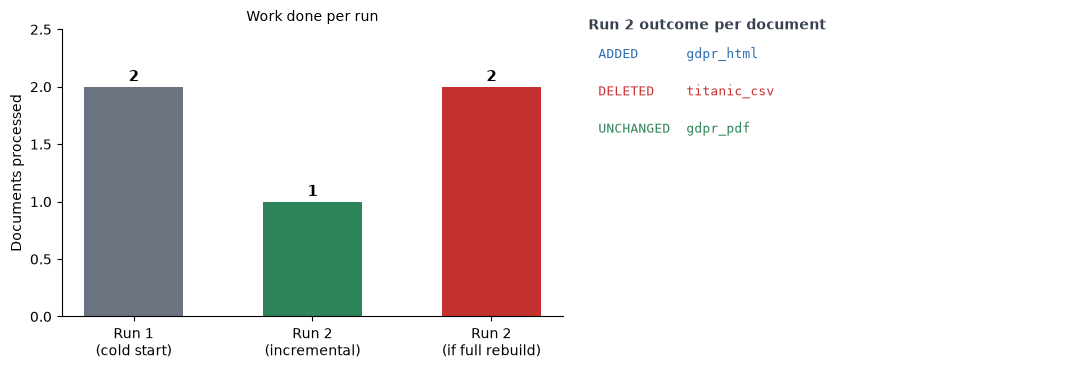

In [12]:
# Render the two-run comparison as a real image, not just printed numbers.
if pymupdf is not None:

    import matplotlib.pyplot as plt

    figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(11, 3.8))

    # LEFT - documents processed per run versus a full rebuild.
    run_labels = ["Run 1\n(cold start)", "Run 2\n(incremental)", "Run 2\n(if full rebuild)"]
    run_values = [documents_processed_run1, documents_processed_run2, full_rebuild_docs]
    run_colours = ["#6b7280", "#2f855a", "#c53030"]

    bars = left_axis.bar(run_labels, run_values, color=run_colours, width=0.55)
    for bar, value in zip(bars, run_values):
        left_axis.text(bar.get_x() + bar.get_width() / 2, value + 0.05, str(value),
                        ha="center", fontsize=11, fontweight="bold")

    left_axis.set_ylabel("Documents processed")
    left_axis.set_title("Work done per run", fontsize=10)
    left_axis.set_ylim(0, max(run_values) * 1.25)
    left_axis.spines[["top", "right"]].set_visible(False)

    # RIGHT - the real outcome of every document in run 2.
    right_axis.axis("off")
    right_axis.set_xlim(0, 1)

    outcome_colours = {"added": "#2b6cb0", "modified": "#b45309",
                        "deleted": "#c53030", "unchanged": "#2f855a"}
    y = 0.9
    right_axis.text(0.02, 1.0, "Run 2 outcome per document", fontsize=10,
                     fontweight="bold", color="#374151")
    for outcome in ["added", "modified", "deleted", "unchanged"]:
        for key in run2_changes[outcome]:
            right_axis.text(0.04, y, f"{outcome.upper():10s} {key}", fontsize=9.5,
                             family="monospace", color=outcome_colours[outcome])
            y -= 0.13

    plt.tight_layout()
    plt.show()

In [13]:
# Clean up the scratch directory this module created.
if scratch.exists():
    shutil.rmtree(scratch)
    print(f"  removed scratch directory: {scratch}")

  removed scratch directory: _incremental_demo


# 7. Module summary

## Key points

1. **Hash content, never trust mtime.** A restored mtime hides a real edit permanently, and the
   failure is silent.
2. **A manifest is the memory** that makes change detection possible. Without a record of the
   previous state, there is nothing to diff against.
3. **Deletion is structurally invisible** to any pipeline that iterates over current sources.
   Only a diff against the previous manifest reveals it.
4. **Derive chunk IDs from content, not position.** A position-based ID is *reused* when the
   text under it changes, so the index silently keeps serving the old text. It looks cheaper
   because it re-embeds less — it re-embeds less because it is not detecting the change.
5. **Idempotency comes free with content-derived IDs** — a retried run overwrites instead of
   duplicating.
6. **Swap atomically and keep the previous version.** Readers never see a half-updated index,
   and rollback is a rename rather than a rebuild.

## Interview answer: "How do you re-index only what changed?"

> I keep a manifest mapping each source document to a SHA-256 of its content, never its mtime,
> because a restored timestamp hides a real edit silently. Each run scans the sources, builds a
> current manifest, and diffs it into added, modified, deleted and unchanged. Unchanged is
> skipped entirely, which is normally most of the corpus. Deletion is the case that needs the
> manifest specifically — a pipeline looping over current sources structurally cannot see a
> document that is gone, so its chunks linger in the index and get cited as current. I derive
> chunk IDs from a hash of the chunk text rather than its position. Position-based IDs get
> reused when the text under them changes, so the index silently serves stale content — it
> looks cheaper only because it is failing to detect the change. Content-derived IDs also make
> the run idempotent on retry, since re-inserting the same chunk overwrites rather than
> duplicates. The new index is built alongside the old one and swapped in
> atomically, keeping the previous version so rollback is a rename.

## Exercises

1. **Deletion audit.** Write a function that finds chunks in the index whose `doc_id` no longer
   appears in the current manifest — an orphan detector for indexes built before this module.
2. **Staleness detector.** Write a function that scans an index built with position-based IDs
   and reports every chunk whose stored text no longer matches the current source — the audit
   you would need before migrating such an index to content-derived IDs.
3. **Crash safety.** Simulate a crash partway through run 2 and verify that re-running it
   produces the correct index, with no duplicates and no missing chunks.
4. **Cost model.** Given a real embedding price per 1,000 tokens, compute the monthly cost of
   full rebuilds versus incremental ingestion for a corpus of 100,000 documents where 2% change
   daily.

## Next: [Module 2j — Tables, Images & Special Formats](../2j.%20Tables%20images%20and%20special%20formats/)

Everything so far treated a document as flowing text. Next: the content that is not prose at
all — tables whose meaning lives in their layout, figures, spreadsheets and email.